# Assignment 1 2AMM10 2025-2026

## Group: [Name Editing]
### Member 1: [Chang Qin]
### Member 2: [Fill in your name]
### Member 3: [Fill in your name]

In [1]:
!pip install kagglehub ipywidgets pandas tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 78.6 MB/s eta 0:00:00


In [2]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

True
Tesla T4


## Task 1

Dataset and visualization

In [3]:
import os
import re
from pathlib import Path
from torch.utils.data import Dataset
from PIL import Image
import kagglehub
import torch
import ipywidgets as widgets
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict

class AppleDataset(Dataset):
    def __init__(self, transform=None, subset="train",class_subset = "main"):
        assert subset in ["train","test"]
        assert class_subset in ["main","new","all"]
        path = kagglehub.dataset_download("moltean/fruits")
        base = Path(path) / "fruits-360_original-size" / "fruits-360-original-size"
        if subset == "train":
            self.path = base / "Training"
        elif subset == "test":
            self.path = base / "Validation"
        self.transform = transform
        all_folders = sorted(os.listdir(self.path))
        self.item_folders = sorted(x for x in all_folders if x.lower().startswith("apple"))
        generator=np.random.default_rng(6)
        generator.shuffle(self.item_folders)
        if class_subset == "main":
            self.item_folders = self.item_folders[:20]
        elif class_subset == "new":
            self.item_folders = self.item_folders[20:]
        self.targets = []
        self.image_paths = []
        for i, folder in enumerate(self.item_folders):
            for img_file in sorted(os.listdir(self.path / folder)):
                if img_file.startswith("r0"):
                    if class_subset=="new":
                        self.targets.append(i+20)
                    else:
                        self.targets.append(i)
                    self.image_paths.append(self.path / folder / img_file)

    def __len__(self):
        return len(self.targets)

    def __getitem__(self, i):
        image = Image.open(self.image_paths[i]).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, self.targets[i]

dataset = AppleDataset()

item_dd = widgets.Dropdown(options=dataset.item_folders, description="Variety:")
frame_slider = widgets.IntSlider(value=0, min=0, max=0, description="Frame:")
output = widgets.Output()


def get_frames(folder):
    return sorted(f for f in os.listdir(dataset.path / folder)
                  if f.startswith("r0_") and f.endswith(".jpg"))

def update_slider(*_):
    frames = get_frames(item_dd.value)
    frame_slider.max = max(0, len(frames) - 1)
    frame_slider.value = min(frame_slider.value, frame_slider.max)
    show_image()

def show_image(*_):
    frames = get_frames(item_dd.value)
    if not frames or frame_slider.value >= len(frames):
        return
    with output:
        clear_output(wait=True)
        img = Image.open(dataset.path / item_dd.value / frames[frame_slider.value])
        fig, ax = plt.subplots(figsize=(4, 4))
        ax.imshow(img)
        ax.set_title(f"{item_dd.value} | frame {frame_slider.value}")
        ax.axis("off")
        plt.tight_layout()
        plt.show()

item_dd.observe(update_slider, names="value")
frame_slider.observe(show_image, names="value")

update_slider()
display(widgets.VBox([item_dd, frame_slider, output]))

Using Colab cache for faster access to the 'fruits' dataset.


In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_data = AppleDataset(subset="train",transform=transform)
test_data = AppleDataset(subset="test",transform=transform)
support_new_data = AppleDataset(subset="train",transform=transform,class_subset="new")
test_new_data = AppleDataset(subset="test",transform=transform,class_subset="new")

# # your code here
class Lambda(nn.Module):
    def __init__(self, func):
        super().__init__()
        self.func = func

    def forward(self, x):
        return self.func(x)

class EmbeddingNet(nn.Module):
    def __init__(self):
        super(EmbeddingNet, self).__init__()

        self.layer1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1, stride=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1, stride=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1, stride=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1, stride=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.AdaptiveAvgPool2d((1,1)),

            Lambda(lambda x: x.view(x.size(0), -1))
        )

        self.embedding = nn.Linear(256, 128)

    def forward(self, x):
        x = self.layer1(x)
        x = self.embedding(x)
        x = F.normalize(x)
        return x

    def get_embedding(self, x):
        return self.forward(x)

Using Colab cache for faster access to the 'fruits' dataset.
Using Colab cache for faster access to the 'fruits' dataset.
Using Colab cache for faster access to the 'fruits' dataset.
Using Colab cache for faster access to the 'fruits' dataset.


In [5]:
from torch.utils.data.sampler import BatchSampler
import numpy as np
class BalancedBatchSampler(BatchSampler):
    """
    Returns batches of size n_classes * n_samples
    """

    def __init__(self, labels, n_classes, n_samples):
        self.labels = labels
        self.labels_set = list(set(self.labels))
        self.label_to_indices = {label: np.where(  np.array(self.labels) == label)[0]
                                 for label in self.labels_set}
        for l in self.labels_set:
            np.random.shuffle(self.label_to_indices[l])
        self.used_label_indices_count = {label: 0 for label in self.labels_set}
        self.count = 0
        self.n_classes = n_classes
        self.n_samples = n_samples
        self.n_dataset = len(self.labels)
        self.batch_size = self.n_samples * self.n_classes

    def __iter__(self):
        self.count = 0
        while self.count + self.batch_size < self.n_dataset:
            classes = np.random.choice(self.labels_set, self.n_classes, replace=False)
            indices = []
            for class_ in classes:
                indices.extend(self.label_to_indices[class_][
                               self.used_label_indices_count[class_]:self.used_label_indices_count[
                                                                         class_] + self.n_samples])
                self.used_label_indices_count[class_] += self.n_samples
                if self.used_label_indices_count[class_] + self.n_samples > len(self.label_to_indices[class_]):
                    np.random.shuffle(self.label_to_indices[class_])
                    self.used_label_indices_count[class_] = 0
            yield indices
            self.count += self.n_classes * self.n_samples

    def __len__(self):
        return self.n_dataset // self.batch_size

In [6]:
train_batch_sampler = BalancedBatchSampler(train_data.targets, n_classes=10, n_samples=25)
test_batch_sampler = BalancedBatchSampler(test_data.targets, n_classes=10, n_samples=25)

triplets_train_loader = torch.utils.data.DataLoader(train_data, batch_sampler=train_batch_sampler)
triplets_test_loader = torch.utils.data.DataLoader(test_data, batch_sampler=test_batch_sampler)

In [7]:
from itertools import combinations

class RandomTripletSelector():
    """
    Select random negative  example for  each positive pair  to create triplets
    """

    def __init__(self):
        super(RandomTripletSelector, self).__init__()

    def get_triplets(self, embeddings, labels):
        labels = labels.cpu().data.numpy()
        triplets = []
        for label in set(labels):
            label_mask = (labels == label)
            label_indices = np.where(label_mask)[0]
            if len(label_indices) < 2:
                continue
            negative_indices = np.where(np.logical_not(label_mask))[0]
            anchor_positives = list(combinations(label_indices, 2))  # All anchor-positive pairs

            temp_triplets = [[anchor_positive[0], anchor_positive[1], np.random.choice(negative_indices)] for anchor_positive in anchor_positives]
            triplets += temp_triplets

        return torch.LongTensor(np.array(triplets))


In [8]:
class TripletLoss(nn.Module):
    """
    Triplets loss
    Takes a batch of embeddings and corresponding labels.
    Triplets are generated using triplet_selector object that take embeddings and targets and return indices of
    triplets
    """

    def __init__(self, margin, triplet_selector):
        super(TripletLoss, self).__init__()
        self.margin = margin
        self.triplet_selector = triplet_selector

    def forward(self, embeddings, target):

        triplets = self.triplet_selector.get_triplets(embeddings, target)

        if embeddings.is_mps:
            triplets = triplets.to('mps')


        anchor_idx= triplets[:, 0]
        positive_idx= triplets[:, 1]
        negative_idx= triplets[:, 2]

        anchor = embeddings[anchor_idx]
        positives = embeddings[positive_idx]
        negatives = embeddings[negative_idx]

        pos_distance = (anchor - positives).pow(2).sum(dim=1)
        neg_distance = (anchor - negatives).pow(2).sum(dim=1)

        losses = torch.clamp(self.margin + pos_distance - neg_distance, min=0)

        return losses.mean()

In [9]:
import numpy as np
from tqdm import tqdm

class Trainer():
    def __init__(self,
                 model: torch.nn.Module,
                 device: torch.device,
                 criterion: torch.nn.Module,
                 optimizer: torch.optim.Optimizer,
                 training_DataLoader: torch.utils.data.Dataset,
                 validation_DataLoader: torch.utils.data.Dataset ,
                 epochs: int
                 ):

        self.model = model
        self.criterion = criterion
        self.optimizer = optimizer
        self.training_DataLoader = training_DataLoader
        self.validation_DataLoader = validation_DataLoader
        self.device = device
        self.epochs = epochs

    def run_trainer(self):

        for epoch in tqdm(range(self.epochs)):

            self.model.train()

            train_losses=[]
            for batch in self.training_DataLoader:

                x,y=batch
                input, target = x.to(self.device), y.to(self.device)
                self.optimizer.zero_grad()
                out = self.model(input)
                loss = self.criterion(out, target)

                loss_value = loss.item()
                train_losses.append(loss_value)

                loss.backward()
                self.optimizer.step()

            self.model.eval()
            valid_losses = []

            for batch in self.validation_DataLoader:

                x,y=batch
                input, target = x.to(self.device), y.to(self.device)

                with torch.no_grad():
                    out = self.model(input)
                    loss = self.criterion(out, target)

                    loss_value = loss.item()
                    valid_losses.append(loss_value)

            print(
                f'EPOCH: {epoch+1:0>{len(str(self.epochs))}}/{self.epochs}',
                end=' '
            )
            print(f'LOSS: {np.mean(train_losses):.4f}',end=' ')
            print(f'VAL-LOSS: {np.mean(valid_losses):.4f}',end='\n')

In [10]:
if torch.mps.is_available():
    device = torch.device('mps')
elif torch.cuda.is_available():
    device=torch.device('cuda')
else:
    device=torch.device('cpu')

embedding_net = EmbeddingNet()
model = embedding_net.to(device)

margin=1

criterion = TripletLoss(margin,  RandomTripletSelector())

optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9)

trainer = Trainer(model=model,
                  device=device,
                  criterion=criterion,
                  optimizer=optimizer,
                  training_DataLoader=triplets_train_loader,
                  validation_DataLoader=triplets_test_loader,
                  epochs=10)

trainer.run_trainer()

 10%|█         | 1/10 [00:43<06:31, 43.49s/it]

EPOCH: 01/10 LOSS: 0.8674 VAL-LOSS: 0.9878


 20%|██        | 2/10 [01:08<04:20, 32.58s/it]

EPOCH: 02/10 LOSS: 0.6722 VAL-LOSS: 0.8014


 30%|███       | 3/10 [01:31<03:16, 28.03s/it]

...

EPOCH: 08/10 LOSS: 0.1130 VAL-LOSS: 0.1334


 90%|█████████ | 9/10 [03:38<00:21, 21.91s/it]

EPOCH: 09/10 LOSS: 0.0966 VAL-LOSS: 0.0850


100%|██████████| 10/10 [04:00<00:00, 24.07s/it]

EPOCH: 10/10 LOSS: 0.0706 VAL-LOSS: 0.0846


In [11]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_data, batch_size=64, shuffle=False)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

support_loader = DataLoader(support_new_data, batch_size=64, shuffle=False)
test_new_loader = DataLoader(test_new_data, batch_size=64, shuffle=False)

In [12]:
def extract_embeddings(model, dataloader, device):
    model.eval()

    embeddings = []
    labels = []

    with torch.no_grad():
        for images, targets in dataloader:

            images = images.to(device)

            emb = model(images)

            embeddings.append(emb.cpu())
            labels.append(targets)

    embeddings = torch.cat(embeddings)
    labels = torch.cat(labels)

    return embeddings, labels

In [13]:
train_embeddings, train_labels = extract_embeddings(
    model,
    train_loader,
    device
)

test_embeddings, test_labels = extract_embeddings(
    model,
    test_loader,
    device
)

In [14]:
def nearest_neighbor_predict(
    train_embeddings,
    train_labels,
    test_embeddings
):

    predictions = []

    for test_emb in test_embeddings:

        distances = torch.norm(
            train_embeddings - test_emb,
            dim=1
        )

        idx = torch.argmin(distances)

        pred = train_labels[idx]

        predictions.append(pred)

    return torch.stack(predictions)


predictions = nearest_neighbor_predict(
    train_embeddings,
    train_labels,
    test_embeddings
)

accuracy = (predictions == test_labels).float().mean()

print("Test Accuracy:", accuracy.item() * 100)

Test Accuracy: 94.79843974113464


In [15]:
support_embeddings, support_labels = extract_embeddings(
    model,
    support_loader,
    device
)

test_new_embeddings, test_new_labels = extract_embeddings(
    model,
    test_new_loader,
    device
)

In [16]:
new_predictions = nearest_neighbor_predict(
    support_embeddings,
    support_labels,
    test_new_embeddings
)

accuracy = (new_predictions == test_new_labels).float().mean()

print("New Test Data Accuracy:", accuracy.item() * 100)

New Test Data Accuracy: 90.39692878723145


## Task 2

In [17]:
import random

def set_seed(seed=42):
    os.environ["PYTHONHASHSEED"] = str(seed)

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    if hasattr(torch.backends, "cudnn"):
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(42)

In [18]:
class GardenDataset(Dataset):
    def __init__(self, transform=None, class_level="item", subset="train", family_subset="main", item_subset="main"):
        assert class_level in ["item","family","both"]
        assert subset in ["train","test"]
        assert family_subset in ["main","new","all"]
        assert item_subset in ["main","new","all"]
        path = kagglehub.dataset_download("moltean/fruits")
        base = Path(path) / "fruits-360_original-size" / "fruits-360-original-size"
        if subset == "train":
            self.path = base / "Training"
        elif subset == "test":
            self.path = base / "Validation"
        self.transform = transform
        self.class_level = class_level

        canonical_items = sorted(
            d for d in os.listdir(base / "Training")
            if (base / "Training" / d).is_dir() and re.fullmatch(r'\S+ \d+', d)
        )
        item_to_family = {it: it.rsplit(' ', 1)[0] for it in canonical_items}
        canonical_families = sorted(set(item_to_family.values()))

        self.item_to_idx = {c: i for i, c in enumerate(canonical_items)}
        self.family_to_idx = {c: i for i, c in enumerate(canonical_families)}

        train_fam_to_items = defaultdict(list)
        for it in canonical_items:
            train_fam_to_items[item_to_family[it]].append(it)
        for fam in train_fam_to_items:
            train_fam_to_items[fam].sort(key=lambda x: int(x.rsplit(' ', 1)[1]))

        new_families = {fam for fam, its in train_fam_to_items.items() if len(its) == 1}
        new_items = set()
        for fam, its in train_fam_to_items.items():
            if len(its) >= 3:
                new_items.add(its[0])

        present = {
            d for d in os.listdir(self.path)
            if (self.path / d).is_dir() and re.fullmatch(r'\S+ \d+', d)
        }
        all_items = [it for it in canonical_items if it in present]

        if family_subset == "main":
            all_items = [it for it in all_items if item_to_family[it] not in new_families]
        elif family_subset == "new":
            all_items = [it for it in all_items if item_to_family[it] in new_families]

        if item_subset == "main":
            all_items = [it for it in all_items if it not in new_items]
        elif item_subset == "new":
            all_items = [it for it in all_items if it in new_items]

        self.items = all_items
        self.item_to_family = {it: item_to_family[it] for it in self.items}
        self.families = sorted(set(self.item_to_family.values()))
        self.new_families = new_families
        self.new_items = new_items

        # Build samples using canonical (global) indices
        self.image_paths = []
        self.targets_item = []
        self.targets_family = []
        for item in self.items:
            item_dir = self.path / item
            item_label = self.item_to_idx[item]
            family_label = self.family_to_idx[item_to_family[item]]
            for img_file in sorted(os.listdir(item_dir)):
                if img_file.endswith('.jpg'):
                    self.image_paths.append(item_dir / img_file)
                    self.targets_item.append(item_label)
                    self.targets_family.append(family_label)

        if class_level == "item":
            self.classes = self.items
            self.class_to_idx = self.item_to_idx
            self.targets = self.targets_item
        elif class_level == "family":
            self.classes = self.families
            self.class_to_idx = self.family_to_idx
            self.targets = self.targets_family

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert("RGB")
        if self.transform:
            image = self.transform(image)
        if self.class_level == "both":
             return image, self.targets_family[idx], self.targets_item[idx]
        return image, self.targets[idx]

    def get_items_for_family(self, family):
        return sorted(item for item, fam in self.item_to_family.items() if fam == family)

dataset = GardenDataset()

family_dd = widgets.Dropdown(options=dataset.families, description="Family:")
item_dd = widgets.Dropdown(options=dataset.get_items_for_family(dataset.families[0]), description="Item:")
frame_slider = widgets.IntSlider(value=0, min=0, max=0, description="Frame:")
output = widgets.Output()


def get_frames(item):
    return sorted(f for f in os.listdir(dataset.path / item) if f.endswith(".jpg"))

def update_items(*_):
    items = dataset.get_items_for_family(family_dd.value)
    item_dd.options = items
    item_dd.value = items[0]

def update_slider(*_):
    frames = get_frames(item_dd.value)
    frame_slider.max = max(0, len(frames) - 1)
    frame_slider.value = min(frame_slider.value, frame_slider.max)
    show_image()

def show_image(*_):
    frames = get_frames(item_dd.value)
    if not frames or frame_slider.value >= len(frames):
        return
    with output:
        clear_output(wait=True)
        img = Image.open(dataset.path / item_dd.value / frames[frame_slider.value])
        fig, ax = plt.subplots(figsize=(4, 4))
        ax.imshow(img)
        ax.set_title(f"{family_dd.value} | {item_dd.value} | frame {frame_slider.value}")
        ax.axis("off")
        plt.tight_layout()
        plt.show()

family_dd.observe(update_items, names="value")
item_dd.observe(update_slider, names="value")
frame_slider.observe(show_image, names="value")

update_slider()
display(widgets.VBox([family_dd, item_dd, frame_slider, output]))

Using Colab cache for faster access to the 'fruits' dataset.


In [19]:
train_data = GardenDataset(subset="train", transform=transform)

# scenario 1
test_data = GardenDataset(subset="test", transform=transform)

# scenario 2
train_data_family = GardenDataset(subset="train", transform=transform, class_level="family")
test_data_family = GardenDataset(subset="test", transform=transform, class_level="family")

# scenario 3
support_all_data = GardenDataset(subset="train", transform=transform, item_subset="all")
test_new_data = GardenDataset(subset="test", transform=transform, item_subset="new")

# scenario 4
support_all_data_family = GardenDataset(subset="train", transform=transform, family_subset="all",class_level="family")
test_new_data_family = GardenDataset(subset="test", transform=transform, family_subset="new",class_level="family")

# your code here
# Task 2 settings

RUN_MODE = "colab_full"   # "local_test" or "colab_full"

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

if RUN_MODE == "local_test":
    IMAGE_SIZE = 64
    BATCH_CLASSES = 4
    BATCH_SAMPLES = 4
    EPOCHS = 1
    LR = 1e-3
    MAX_ITEMS = 8
elif RUN_MODE == "colab_full":
    IMAGE_SIZE = 128
    BATCH_CLASSES = 16
    BATCH_SAMPLES = 8
    EPOCHS = 20
    LR = 1e-3
    MAX_ITEMS = None
else:
    raise ValueError("RUN_MODE must be 'local_test' or 'colab_full'")

print("RUN_MODE:", RUN_MODE)
print("device:", device)



Using Colab cache for faster access to the 'fruits' dataset.
Using Colab cache for faster access to the 'fruits' dataset.
Using Colab cache for faster access to the 'fruits' dataset.
Using Colab cache for faster access to the 'fruits' dataset.
Using Colab cache for faster access to the 'fruits' dataset.
Using Colab cache for faster access to the 'fruits' dataset.
Using Colab cache for faster access to the 'fruits' dataset.
Using Colab cache for faster access to the 'fruits' dataset.
RUN_MODE: colab_full
device: cuda


In [20]:
from torch.utils.data import Subset
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor()
])

def maybe_subset(dataset, max_samples):
    if max_samples is None:
        return dataset

    n = min(max_samples, len(dataset))
    return Subset(dataset, range(n))



In [21]:
class EmbeddingNet(nn.Module):
    def __init__(self, embedding_dim=64):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.projection = nn.Linear(128 * 16 * 16, embedding_dim)

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.projection(x)
        x = F.normalize(x, dim=1)
        return x



In [22]:



def small_balanced_subset(dataset, n_classes=8, n_samples=8):
    labels = np.array(dataset.targets)
    selected = []

    for label in sorted(set(labels))[:n_classes]:
        idx = np.where(labels == label)[0][:n_samples]
        selected.extend(idx.tolist())

    subset = Subset(dataset, selected)
    subset_labels = [dataset.targets[i] for i in selected]

    return subset, subset_labels


if RUN_MODE == "local_test":
    train_for_fit, train_labels = small_balanced_subset(
        train_data,
        n_classes=8,
        n_samples=8
    )

    test_for_fit, test_labels_for_sampler = small_balanced_subset(
        test_data,
        n_classes=8,
        n_samples=8
    )
else:
    train_for_fit = train_data
    test_for_fit = test_data

    train_labels = train_data.targets
    test_labels_for_sampler = test_data.targets


train_batch_sampler = BalancedBatchSampler(
    train_labels,
    n_classes=min(BATCH_CLASSES, len(set(train_labels))),
    n_samples=BATCH_SAMPLES
)

test_batch_sampler = BalancedBatchSampler(
    test_labels_for_sampler,
    n_classes=min(BATCH_CLASSES, len(set(test_labels_for_sampler))),
    n_samples=BATCH_SAMPLES
)

train_loader = DataLoader(
    train_for_fit,
    batch_sampler=train_batch_sampler
)

test_loader = DataLoader(
    test_for_fit,
    batch_sampler=test_batch_sampler
)

set_seed(42)

model = EmbeddingNet().to(device)

criterion = TripletLoss(
    margin=1,
    triplet_selector=RandomTripletSelector()
)

optimizer = torch.optim.Adam(model.parameters(), lr=LR)

trainer = Trainer(
    model=model,
    device=device,
    criterion=criterion,
    optimizer=optimizer,
    training_DataLoader=train_loader,
    validation_DataLoader=test_loader,
    epochs=EPOCHS
)

trainer.run_trainer()


  5%|▌         | 1/20 [05:03<1:36:07, 303.53s/it]

EPOCH: 01/20 LOSS: 0.1894 VAL-LOSS: 0.0887


 10%|█         | 2/20 [08:25<1:13:10, 243.93s/it]

EPOCH: 02/20 LOSS: 0.0733 VAL-LOSS: 0.0486


 15%|█▌        | 3/20 [11:23<1:00:36, 213.91s/it]

...

EPOCH: 18/20 LOSS: 0.0024 VAL-LOSS: 0.0016


 95%|█████████▌| 19/20 [59:27<03:03, 183.22s/it]

EPOCH: 19/20 LOSS: 0.0020 VAL-LOSS: 0.0014


100%|██████████| 20/20 [1:02:30<00:00, 187.51s/it]

EPOCH: 20/20 LOSS: 0.0010 VAL-LOSS: 0.0010


In [23]:
torch.save({
    "model_state_dict": model.state_dict(),
    "image_size": IMAGE_SIZE,
    "embedding_dim": 64,
    "run_mode": RUN_MODE,
    "epochs": EPOCHS,
}, "task2_embedding_model.pth")

print("Saved model to task2_embedding_model.pth")



Saved model to task2_embedding_model.pth


In [24]:
def extract_embeddings(model, dataset, batch_size, device):
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    model.eval()
    all_embeddings = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)

            embeddings = model(images).cpu()

            all_embeddings.append(embeddings)
            all_labels.append(labels.cpu())

    all_embeddings = torch.cat(all_embeddings)
    all_labels = torch.cat(all_labels)

    return all_embeddings, all_labels



In [25]:
print("train_data:", len(train_data))
print("test_data:", len(test_data))
print("train_data_family:", len(train_data_family))
print("test_data_family:", len(test_data_family))
print("support_all_data:", len(support_all_data))
print("test_new_data:", len(test_new_data))
print("support_all_data_family:", len(support_all_data_family))
print("test_new_data_family:", len(test_new_data_family))



train_data: 27678
test_data: 13843
train_data_family: 27678
test_data_family: 13843
support_all_data: 31622
test_new_data: 1971
support_all_data_family: 31909
test_new_data_family: 2119


In [26]:
support_embeddings_s1, support_labels_s1 = extract_embeddings(
    model,
    train_data,
    64,
    device
)

test_embeddings_s1, test_labels_s1 = extract_embeddings(
    model,
    test_data,
    64,
    device
)


def compute_prototypes(embeddings, labels):
    prototypes = {}

    for label in torch.unique(labels):
        class_embeddings = embeddings[labels == label]
        prototype = class_embeddings.mean(dim=0)
        prototype = F.normalize(prototype, dim=0)
        prototypes[int(label.item())] = prototype

    return prototypes


def prototype_predict(test_embeddings, prototypes):
    prototype_labels = torch.tensor(list(prototypes.keys()))
    prototype_embeddings = torch.stack(list(prototypes.values()))

    scores = torch.matmul(test_embeddings, prototype_embeddings.T)
    nearest = torch.argmax(scores, dim=1)

    return prototype_labels[nearest]


prototypes_s1 = compute_prototypes(
    support_embeddings_s1,
    support_labels_s1
)

predictions_s1 = prototype_predict(
    test_embeddings_s1,
    prototypes_s1
)

accuracy_s1 = (predictions_s1 == test_labels_s1).float().mean()

print("Scenario 1 item accuracy:", accuracy_s1.item() * 100)


Scenario 1 item accuracy: 100.0


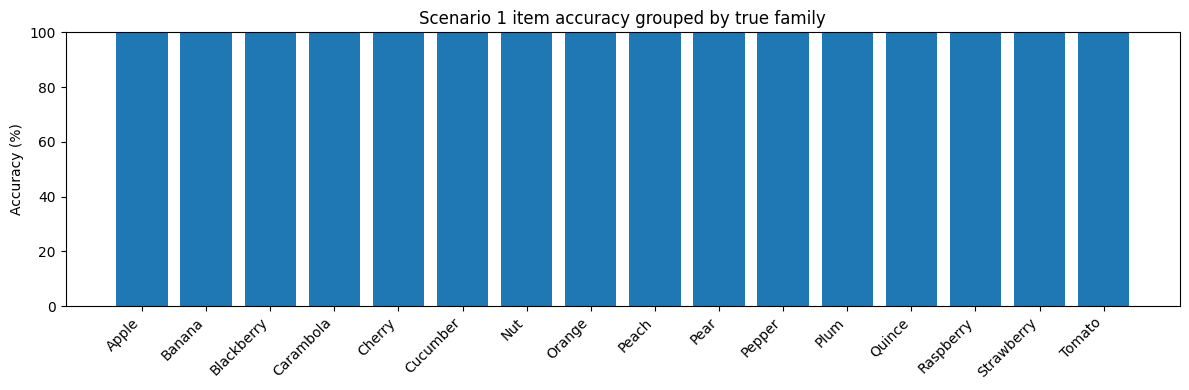

In [27]:
item_idx_to_name = {idx: name for name, idx in test_data.item_to_idx.items()}

true_family_names = []
for label in test_labels_s1:
    item_name = item_idx_to_name[int(label.item())]
    family_name = test_data.item_to_family[item_name]
    true_family_names.append(family_name)

family_accuracy = {}

for family in sorted(set(true_family_names)):
    mask = torch.tensor([name == family for name in true_family_names])
    acc = (predictions_s1[mask] == test_labels_s1[mask]).float().mean().item()
    family_accuracy[family] = acc

plt.figure(figsize=(12, 4))
plt.bar(family_accuracy.keys(), [v * 100 for v in family_accuracy.values()])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 100)
plt.title("Scenario 1 item accuracy grouped by true family")
plt.tight_layout()
plt.show()


In [34]:
item_idx_to_name = {idx: name for name, idx in test_data.item_to_idx.items()}

family_correct = {}
family_total = {}

for pred, true in zip(predictions_s1, test_labels_s1):
    item_name = item_idx_to_name[int(true.item())]
    family_name = test_data.item_to_family[item_name]

    family_total[family_name] = family_total.get(family_name, 0) + 1
    family_correct[family_name] = family_correct.get(family_name, 0) + int(pred.item() == true.item())

family_accuracy = {
    family: family_correct[family] / family_total[family]
    for family in family_total
}

hardest_family = min(family_accuracy, key=family_accuracy.get)

print("Hardest family in Scenario 1:")
print("Family:", hardest_family)
print("Accuracy:", family_accuracy[hardest_family] * 100)
print("Correct / Total:", family_correct[hardest_family], "/", family_total[hardest_family])

Hardest family in Scenario 1:
Family: Apple
Accuracy: 100.0
Correct / Total: 3282 / 3282


In [28]:
support_embeddings_s2, support_labels_s2 = extract_embeddings(
    model,
    train_data_family,
    64,
    device
)

test_embeddings_s2, test_labels_s2 = extract_embeddings(
    model,
    test_data_family,
    64,
    device
)

prototypes_s2 = compute_prototypes(
    support_embeddings_s2,
    support_labels_s2
)

predictions_s2 = prototype_predict(
    test_embeddings_s2,
    prototypes_s2
)

accuracy_s2 = (predictions_s2 == test_labels_s2).float().mean()

print("Scenario 2 family accuracy:", accuracy_s2.item() * 100)

Scenario 2 family accuracy: 100.0


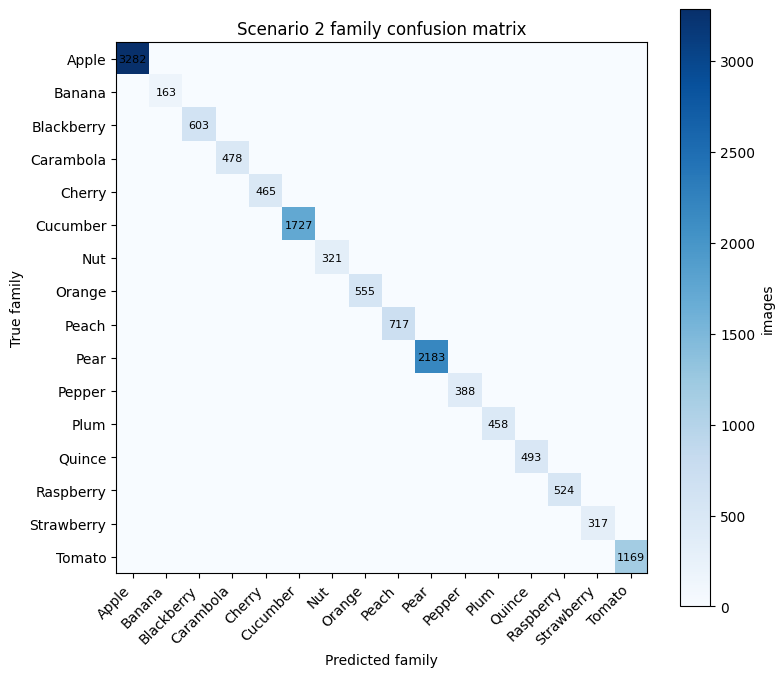

In [29]:
labels_s2 = sorted(set(test_labels_s2.tolist()) | set(predictions_s2.tolist()))
label_to_pos_s2 = {label: i for i, label in enumerate(labels_s2)}

cm_s2 = np.zeros((len(labels_s2), len(labels_s2)), dtype=int)

for true_label, pred_label in zip(test_labels_s2.tolist(), predictions_s2.tolist()):
    i = label_to_pos_s2[true_label]
    j = label_to_pos_s2[pred_label]
    cm_s2[i, j] += 1

idx_to_family = {idx: family for family, idx in test_data_family.family_to_idx.items()}
family_names_s2 = [idx_to_family[label] for label in labels_s2]

plt.figure(figsize=(8, 7))
plt.imshow(cm_s2, cmap="Blues")
plt.colorbar(label="images")

plt.xticks(range(len(family_names_s2)), family_names_s2, rotation=45, ha="right")
plt.yticks(range(len(family_names_s2)), family_names_s2)

plt.xlabel("Predicted family")
plt.ylabel("True family")
plt.title("Scenario 2 family confusion matrix")

for i in range(cm_s2.shape[0]):
    for j in range(cm_s2.shape[1]):
        if cm_s2[i, j] > 0:
            plt.text(j, i, cm_s2[i, j], ha="center", va="center", fontsize=8)

plt.tight_layout()
plt.show()

In [30]:
support_embeddings_s3, support_labels_s3 = extract_embeddings(
    model,
    support_all_data,
    64,
    device
)

test_embeddings_s3, test_labels_s3 = extract_embeddings(
    model,
    test_new_data,
    64,
    device
)

prototypes_s3 = compute_prototypes(
    support_embeddings_s3,
    support_labels_s3
)

predictions_s3 = prototype_predict(
    test_embeddings_s3,
    prototypes_s3
)

accuracy_s3 = (predictions_s3 == test_labels_s3).float().mean()

print("Scenario 3 new item accuracy:", accuracy_s3.item() * 100)


Scenario 3 new item accuracy: 100.0


In [31]:
support_embeddings_s4, support_labels_s4 = extract_embeddings(
    model,
    support_all_data_family,
    64,
    device
)

test_embeddings_s4, test_labels_s4 = extract_embeddings(
    model,
    test_new_data_family,
    64,
    device
)

prototypes_s4 = compute_prototypes(
    support_embeddings_s4,
    support_labels_s4
)

predictions_s4 = prototype_predict(
    test_embeddings_s4,
    prototypes_s4
)

accuracy_s4 = (predictions_s4 == test_labels_s4).float().mean()

print("Scenario 4 new family accuracy:", accuracy_s4.item() * 100)


Scenario 4 new family accuracy: 94.62010264396667


## Task 3

In [32]:
train_data_both = GardenDataset(class_level="both",transform=transform,subset="train",family_subset="main",item_subset="main")

test_data_both = GardenDataset(class_level="both",transform=transform,subset="test",family_subset="main",item_subset="main")

# your code here

Using Colab cache for faster access to the 'fruits' dataset.
Using Colab cache for faster access to the 'fruits' dataset.


## Task 4

In [33]:
class BlackoutPixels:
    """Transform that randomly sets x% of pixels to black (0).

    Args:
        fraction: Fraction of pixels to black out (0.0 to 1.0).
    """
    def __init__(self, fraction=0.1):
        self.fraction = fraction

    def __call__(self, img):
        # img shape: (C, H, W)
        _, h, w = img.shape
        num_pixels = h * w
        num_black = int(num_pixels * self.fraction)

        # Random pixel indices to black out
        indices = torch.randperm(num_pixels)[:num_black]
        rows = indices // w
        cols = indices % w

        img = img.clone()
        img[:, rows, cols] = 0.0
        return img

def get_anomaly_dataset(fraction):
    transform = transforms.Compose([
        BlackoutPixels(fraction=fraction),
        ... # your transforms here
    ])
    return GardenDataset(subset="test", transform=transform, family_subset="main", item_subset="main")

# your code here
